In [1]:
# import utils and reload automatically in jupyter
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('..')

import os
from types import SimpleNamespace
import numpy as np
import matplotlib.pyplot as plt
import h5py
from src.utils import processIndDEMData, plotAIACube, processIndAIAData
from src.utils import compute_photon_error_bounds


# torch
import torch
import torch.nn as nn

args = {
    "crop": "",
    "dev": "mps",
    "preprocess": "",
    "corr_table": "aia_corr.cvs"
}
args = SimpleNamespace(**args)  # convert dict to namespace

print("mps device:", torch.backends.mps.is_available())
# set device
if args.dev == "mps":
    device = torch.device("mps")
elif args.dev == "cuda":
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
device = torch.device("cpu")  # force CPU for now
print("Using device:", device)
print("device:", device)

wavelengths = [94, 131, 171, 193, 211, 335]

mps device: False
Using device: cpu
device: cpu


In [3]:
# load the npz
npz_path = os.path.join("../data/input/train2", "20240520_1200.npz")
npz = np.load(npz_path)
print("npz keys:", npz.files)

npz keys: ['DEMCube', 'DEMCubeShape', 'AIACube', 'AIAErrors', 'AIACubeShape', 'logT', 'scaleFactor']


In [4]:
DEMCube = npz["DEMCube"]
AIACube = npz["AIACube"]

In [5]:
# original data path
data_path = os.path.join("../data/input/train", "20240520_1200")

_, AIAErrors, _= processIndAIAData(data_path, args=args)

reading AIA data from ../data/input/train\20240520_1200
AIA maps loaded
Exposure times loaded
Using correction table aia_corr.cvs
Correction table loaded
Exposure times and degradation factors loaded
Updating pointing and registering AIA maps
Applying degradation correction


In [6]:
print(AIACube.dtype)    
print(DEMCube.dtype)
print(AIAErrors.dtype) 

|S322327959
|S6231007
float64


In [7]:
import numpy as np
from numcodecs import Blosc, BitRound

dem_compressor = Blosc(cname='zstd', clevel=5, shuffle=2)
aia_compressor = Blosc(cname='zstd', clevel=4, shuffle=2)
dem_filter = BitRound(keepbits=12)

# Decodificar DEMCube
DEMCubeShape = tuple(npz['DEMCubeShape'])
DEMCube = np.frombuffer(
    dem_filter.decode(dem_compressor.decode(npz['DEMCube'].tobytes())),
    dtype=np.float32
).reshape(DEMCubeShape)

# Decodificar AIACube
AIACubeShape = tuple(npz['AIACubeShape'])
AIACube = np.frombuffer(
    aia_compressor.decode(npz['AIACube'].tobytes()),
    dtype=np.float32
).reshape(AIACubeShape)

# Decodificar AIAErrors (mismo compresor que AIA)
AIAErrors = np.frombuffer(
    aia_compressor.decode(npz['AIAErrors'].tobytes()),
    dtype=np.float32
).reshape(AIACubeShape)

print(AIACube.dtype, AIACube.shape)
print(DEMCube.dtype, DEMCube.shape)
print(AIAErrors.dtype, AIAErrors.shape)

float32 (6, 4096, 4096)
float32 (18, 512, 512)
float32 (6, 4096, 4096)


In [8]:
from src.utils import unfold_tensor
aia_patches = unfold_tensor(AIACube)
dem_patches = unfold_tensor(DEMCube, patch_size=32, stride=32)
aia_errors_patches = unfold_tensor(AIAErrors)

In [9]:
# now with DataLoader
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
class SimpleAIAData(Dataset):
    def __init__(self, data):
        self.len = None
        self.aia_ds = data[0]
        self.err_ds = data[1]

    def __getitem__(self, idx):

        aia_patch = self.aia_ds[idx]
        aia_error = self.err_ds[idx]

        aia_patch = torch.from_numpy(aia_patch).double()
        aia_error = torch.from_numpy(aia_error).double()
        return aia_patch, aia_error

    def __len__(self):
        if self.len is None:
            self.len = len(self.aia_ds)
        return self.len

aia_data = SimpleAIAData((aia_patches, aia_errors_patches))

In [10]:
dem_patches.shape

(256, 18, 32, 32)

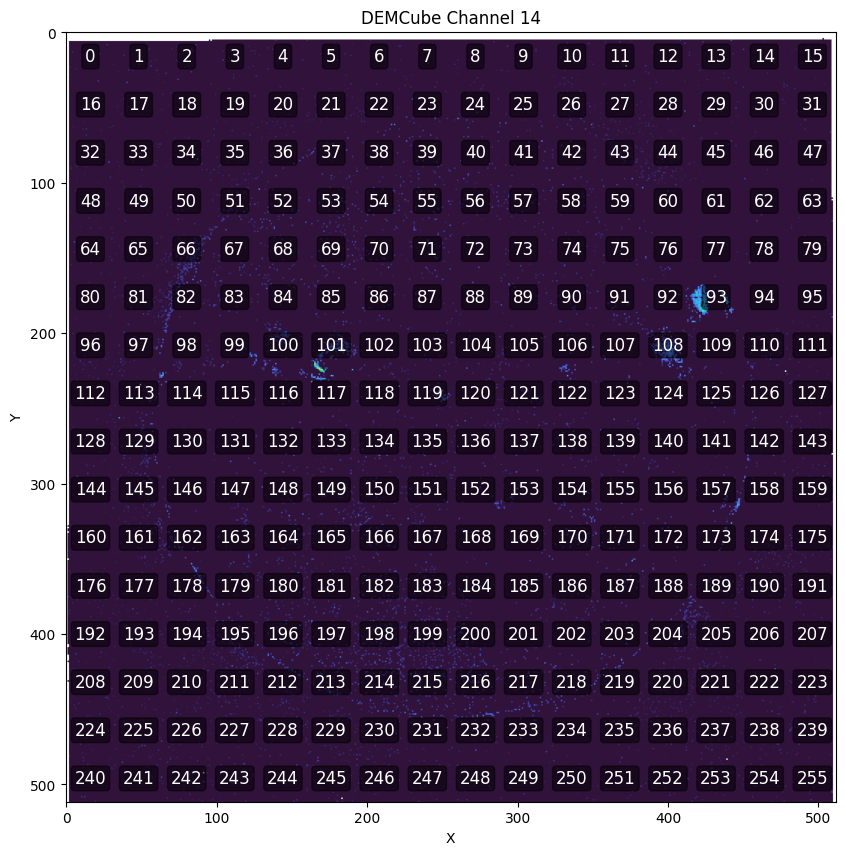

In [12]:
# Plot DEMCube channel 14 with patch labels
channel = 14
patch_size = 32
cube = DEMCube[channel]

plt.figure(figsize=(10, 10))
plt.imshow(cube**0.5, cmap="turbo", vmin=0, vmax=10)
plt.title(f"DEMCube Channel {channel}")

# Overlay patch labels
n_patches_y = cube.shape[0] // patch_size
n_patches_x = cube.shape[1] // patch_size

for idx_y in range(n_patches_y):
    for idx_x in range(n_patches_x):
        idx = idx_y * n_patches_x + idx_x
        y = idx_y * patch_size + patch_size // 2
        x = idx_x * patch_size + patch_size // 2
        plt.text(x, y, str(idx), color="white", fontsize=12, ha="center", va="center", bbox=dict(facecolor='black', alpha=0.5, boxstyle='round,pad=0.2'))

plt.xlabel("X")
plt.ylabel("Y")
plt.show()

i: 114
aia shape: torch.Size([6, 256, 256])
dem shape: torch.Size([6, 256, 256])


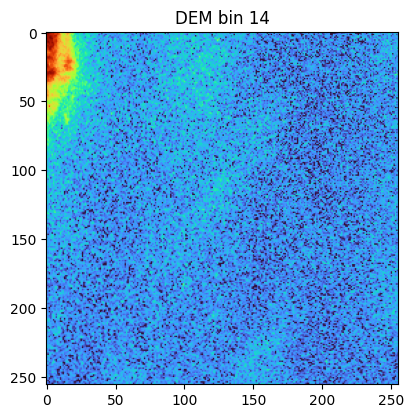

i: 115
aia shape: torch.Size([6, 256, 256])
dem shape: torch.Size([6, 256, 256])


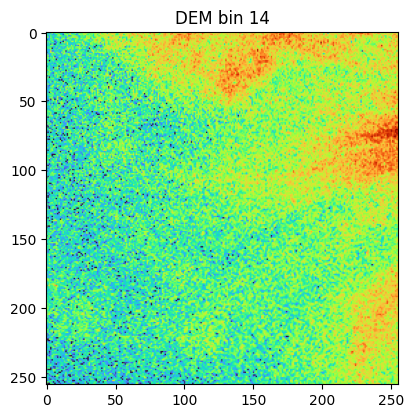

i: 116
aia shape: torch.Size([6, 256, 256])
dem shape: torch.Size([6, 256, 256])


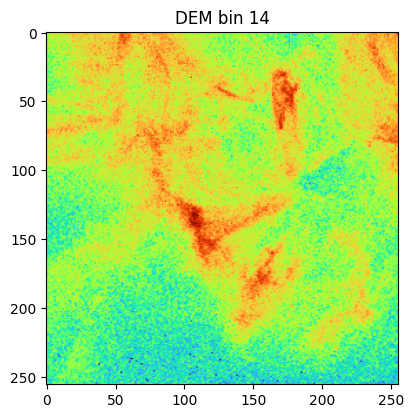

In [13]:
# plot all dem_patches in bin 14 to look for one that i want to use, do it after idx 150

for i, (aia, err) in enumerate(aia_data):
    if i < 114:
        continue
    if i > 116:
        break
    print("i:", i)
    print("aia shape:", aia.shape)
    print("dem shape:", err.shape)
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(err[0]**0.5, cmap="turbo")
    plt.title("DEM bin 14")
    plt.show()




In [14]:
# change dem_data to return only the patch 115

# subsample at 115
aia_ds = torch.utils.data.Subset(aia_data, [116])

# Since dem_data contains only one patch, set shuffle=False
aia_loader = DataLoader(
    aia_ds,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

In [15]:
from src.model import DEMBasisNet, BasisNetReLU
model = BasisNetReLU().to(device)

In [16]:
from src.utils import getBasis
RData = np.load("../RData.npz")
R, logT = RData['R'], RData['logT']
wavelengths = [94, 131, 171, 193, 211, 335]
scale = 10**26
R = (R * scale).astype(np.float64)
basisAlphas = list(map(float, "0.0_0.1_0.2".split("_")))
B = getBasis(R, logT, basisAlphas)

RData = {'R': R, 'B': B}
# total matrix is R (nObs x nLogTBins) @ B (nLogTBins x nBasis)
D = R@B
D = torch.tensor(D, dtype=torch.float64).to(device)  # [N, n_temps]
B = torch.tensor(B, dtype=torch.float64).to(device)  # [nLogTBins, n_basis]

In [17]:
# change

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [18]:
from src.losses import BarrierLoss
args.alpha_l1 = 1
args.alpha_l2 = 0
args.mu = 1
args.alpha_fit = 0
barrier_loss = BarrierLoss(D=D, B=B, R=R, args=args)

In [19]:
# get the batch from the dataloader
aia_input, aia_errors = next(iter(aia_loader))
aia_input = aia_input[:, :, 100:101, 100:101]
aia_errors = aia_errors[:, :, 100:101, 100:101]

c:\Users\Usuario\anaconda3\envs\dem-dl\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [20]:
aia_input.shape, aia_errors.shape

(torch.Size([1, 6, 1, 1]), torch.Size([1, 6, 1, 1]))

In [21]:
model = model.double().to(device)
model.train()

for i in range(10000):
    aia_input = aia_input.to(device)
    aia_errors = aia_errors.to(device)
    optimizer.zero_grad()
    output = model(aia_input)

    # flatten the aia observations and basis outputs for loss
    aia_obs_flat = aia_input.permute(0, 2, 3, 1).reshape(-1, aia_input.shape[1])  # [B * H * W, n_channels]
    output_flat = output.permute(0, 2, 3, 1).reshape(-1, output.shape[1]) # [B * H * W, n_basis]

    # compute lower and upper bounds and flatten them
    lb, ub = compute_photon_error_bounds(aia_obs=aia_input, aia_errors=aia_errors)
    lb = lb.reshape(-1, lb.shape[-1])  # [B*H*W, n_channels]
    ub = ub.reshape(-1, ub.shape[-1])  # [B*H*W, n_channels]

    loss = barrier_loss(output_flat, aia_obs=aia_obs_flat, lb=lb, ub=ub)
    # check l1 
    l1_check = torch.sum(torch.abs(output_flat), dim=1)  # [B*H*W]
    Dx = torch.matmul(output_flat, D.T)
    ub_check = torch.sum(torch.relu(lb - Dx), dim=1)   # [B*H*W]
    lb_check = torch.sum(torch.relu(Dx - ub), dim=1)  # [B*H*W]
    
    
    loss.backward()
    optimizer.step()
    if i % 1000 == 0:
        print(f"Step {i}, loss: {loss.item():.6f}, L1 check: {l1_check.mean().item():.6f}, "
              f"UB check: {ub_check.mean().item():.6f}, LB check: {lb_check.mean().item():.6f}")

Step 0, loss: 194459536.546187, L1 check: 240.939553, UB check: 0.000000, LB check: 19640.215493
Step 1000, loss: 84.979797, L1 check: 62.817327, UB check: 0.106645, LB check: 5.132271
Step 2000, loss: 65.356598, L1 check: 57.058674, UB check: 0.059727, LB check: 2.880147
Step 3000, loss: 61.026834, L1 check: 53.474159, UB check: 0.057446, LB check: 2.747758
Step 4000, loss: 53.524381, L1 check: 47.102316, UB check: 0.351977, LB check: 2.516074
Step 5000, loss: 51.053180, L1 check: 46.053672, UB check: 0.219213, LB check: 2.226660
Step 6000, loss: 53.669004, L1 check: 45.902515, UB check: 0.217062, LB check: 3.919561
Step 7000, loss: 48.546966, L1 check: 46.979162, UB check: 0.207059, LB check: 1.239139
Step 8000, loss: 335.771710, L1 check: 46.510740, UB check: 4.704120, LB check: 28.061074
Step 9000, loss: 335.771689, L1 check: 46.511488, UB check: 4.699863, LB check: 28.060273


BP train:

In [22]:
x = torch.nn.Parameter(torch.zeros(1, 54, device=device, dtype=torch.float64)) # [B, n_basis]

In [23]:
D_pinv = torch.linalg.pinv(D)          # [n_basis, n_obs]
# 2) initialize x0 by projecting that onto ≥0
x0 = torch.relu(aia_obs_flat @ D_pinv.T)      # [B, n_basis]
x    = torch.nn.Parameter(x0.clone())

In [ ]:
def inv_softplus(x):
    return x + torch.log(-torch.expm1(-x))

resultlpclone = result_lp.clone()
# change 0 to 1e-8
resultlpclone[resultlpclone == 0] = 1e-4
resultinv = inv_softplus(resultlpclone)  # reset x to ones
x = torch.nn.Parameter(resultinv)  # reset x to ones

In [27]:
optimizer = torch.optim.Adam([x], lr=1e-4)

In [28]:

for step in range(100000):
    aia_input = aia_input.to(device)
    aia_errors = aia_errors.to(device)
    optimizer.zero_grad()
    aia_obs_flat = aia_input.permute(0, 2, 3, 1).reshape(-1, aia_input.shape[1])  # [B * H * W, n_channels]

    # compute lower and upper bounds and flatten them
    lb, ub = compute_photon_error_bounds(aia_obs=aia_input, aia_errors=aia_errors)
    lb = lb.reshape(-1, lb.shape[-1])  # [B*H*W, n_channels]
    ub = ub.reshape(-1, ub.shape[-1])  # [B*H*W, n_channels]
    loss = barrier_loss(nn.functional.softplus(x), aia_obs=aia_obs_flat, lb=lb, ub=ub)
    loss.backward()
    optimizer.step()

    if step % 10000 == 0:
        print(f"Step {step}, loss: {loss.item():.6f}")

x_star = nn.functional.softplus(x) # [B, n_basis]


Step 0, loss: 7229892.439259
Step 10000, loss: 1515321.672464
Step 20000, loss: 132288.758931
Step 30000, loss: 15569.170421
Step 40000, loss: 5162.990993
Step 50000, loss: 771.458299
Step 60000, loss: 65.196863
Step 70000, loss: 55.554304
Step 80000, loss: 48.702871
Step 90000, loss: 44.484691


In [26]:
from src.losses import BarrierLoss
args.alpha_l1 = 1
args.alpha_l2 = 0
args.mu = 1
args.alpha_fit = 0
barrier_loss = BarrierLoss(D=D, B=B, R=R, args=args)

In [25]:
device = torch.device("cpu")

def closure():
    aia_input_dev = aia_input.cpu()
    aia_errors_dev = aia_errors.cpu()
    lbfgs.zero_grad()
    
    aia_obs_flat = aia_input_dev.permute(0, 2, 3, 1).reshape(-1, aia_input_dev.shape[1])  # [B * H * W, n_channels]
    # compute lower and upper bounds and flatten them
    lb, ub = compute_photon_error_bounds(aia_obs=aia_input_dev, aia_errors=aia_errors_dev)
    lb = lb.reshape(-1, lb.shape[-1])  # [B*H*W, n_channels]
    ub = ub.reshape(-1, ub.shape[-1])  # [B*H*W, n_channels]
    x = nn.functional.softplus(x_lbfgs)  # ensure x is positive
    loss = barrier_loss(x, aia_obs=aia_obs_flat, lb=lb, ub=ub)
    loss.backward()
    return loss

x_lbfgs = torch.ones(1, 54, device=device, requires_grad=True, dtype=torch.float64)
#x_lbfgs = x
lbfgs = torch.optim.LBFGS([x_lbfgs], lr=1e-6, max_iter=100, line_search_fn='strong_wolfe', tolerance_change=1e-12, tolerance_grad=1e-32)

barrier_loss.mu = 1000
for step in range(10000):
    loss = lbfgs.step(closure)
    if step % 1000 == 0:
        print(f"Step {step}, loss: {loss.item():.6f}")
        barrier_loss.mu *= 1
x_star = nn.functional.softplus(x_lbfgs)  # [B, n_basis]

Step 0, loss: 7491505636.040195
Step 1000, loss: 38.856686
Step 2000, loss: 38.856686
Step 3000, loss: 38.856686
Step 4000, loss: 38.856686
Step 5000, loss: 38.856686
Step 6000, loss: 38.856686
Step 7000, loss: 38.856686
Step 8000, loss: 38.856686
Step 9000, loss: 38.856686


In [26]:
from scipy.optimize import minimize

# 1) extract your initial x from the torch parameter
x0_np = x_lbfgs.detach().cpu().numpy().reshape(-1)

def obj_and_grad(x_np):
    # wrap into torch, enable grad
    x_t = torch.tensor(x_np, dtype=torch.float64, requires_grad=True)
    # enforce positivity
    x_pos = nn.functional.softplus(x_t)
    # compute loss (uses your existing barrier_loss, aia_obs_flat, lb, ub on CPU)
    loss_t = barrier_loss(x_pos, aia_obs_flat, lb, ub)
    loss = loss_t.item()
    # backprop to get ∂loss/∂x_t
    loss_t.backward()
    grad = x_t.grad.numpy()
    return loss, grad

# 2) call SciPy minimize
res = minimize(
    obj_and_grad,
    x0_np,
    method='L-BFGS-B',
    jac=True,
    options={'maxiter': 100, 'disp': True}
)

# 3) recover the positive solution via softplus
x_star_scipy = nn.functional.softplus(
    torch.tensor(res.x, dtype=torch.float64)
).numpy()

print("SciPy result:", res)
print("x_star_scipy:", x_star_scipy)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_3400\776933621.py:20: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


IndexError: Dimension out of range (expected to be in range of [-1, 0], but got 1)

In [27]:
print(torch.round(x_star.data, decimals=2))

tensor([[ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         15.9600,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000, 10.3000,  4.7700,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.4600,  1.5000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  5.8800,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000]],
       dtype=torch.float64)


In [ ]:
result_lp

In [28]:
# l1 check
print("L1 norm of x:", torch.sum(torch.abs(x_star)).item())

L1 norm of x: 38.85070795559021


In [29]:
x_basis = x_star.detach()

In [30]:
# forward pass
with torch.no_grad():
    #x_basis = model(aia_input)  # [1, n_basis, H, W]
    #x_basis = x_basis.permute(0, 2, 3, 1).reshape(-1, x_basis.shape[1])  # [N, n_basis]
    dem_pred = torch.matmul(x_basis, B.T)  # [N, n_temps]
    # recover dimensions B, 18, H, W
    dem_pred_cube = dem_pred.reshape(aia_input.size(0), aia_input.shape[2], aia_input.shape[3], -1).permute(0, 3, 1, 2).cpu().numpy()  # [B, n_temps, H, W]

print("DEM shape:", dem_pred_cube.shape)

DEM shape: (1, 18, 1, 1)


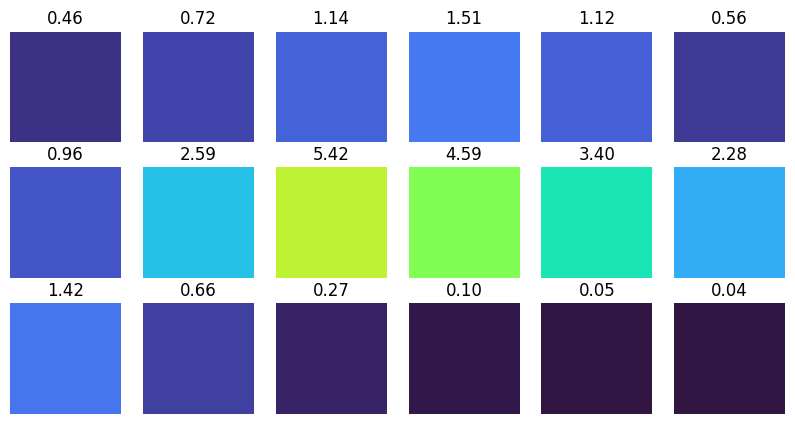

In [31]:
# plot the DEM cube
plt.figure(figsize=(10, 5))
for i in range(18):
    plt.subplot(3, 6, i + 1)
    plt.imshow(dem_pred_cube[0, i]**0.5, cmap="turbo", vmin=0, vmax=10)
    plt.title(f"{dem_pred_cube[0, i, 0, 0]**0.5:.2f}")
    # plot the value in the center
    plt.axis("off")
plt.savefig("dem_pred_cube.pdf", dpi=300, bbox_inches='tight')

In [ ]:
dem_true = dem_patches[115]
dem_true = dem_true[:, 100:101, 100:101]  # take the same patch as aia_input
# plot the DEM cube
plt.figure(figsize=(10, 5))
for i in range(18):
    plt.subplot(3, 6, i + 1)
    plt.imshow(dem_true[i]**0.5, cmap="turbo", vmin=0, vmax=10)
    plt.title(f"{dem_true[i, 0, 0]**0.5:.2f}")
    plt.axis("off")
plt.savefig("dem_true.pdf", dpi=300, bbox_inches='tight')

TypeError: slice indices must be integers or None or have an __index__ method

NameError: name 'dem_true' is not defined

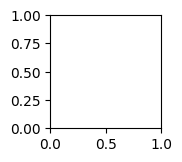

In [33]:
# now, difference, colormap bwr to visualize the difference
plt.figure(figsize=(10, 5))
for i in range(18):
    plt.subplot(3, 6, i + 1)
    diff = dem_pred_cube[0, i, 0, 0]**0.5 - dem_true[i, 0, 0]**0.5 # difference at the center pixel
    diff = diff.reshape(1, 1)  # reshape to 2D for imshow
    plt.imshow(diff, cmap="bwr", vmin=-2, vmax=2)
    plt.title(f"{diff[0, 0]:.2f}")
    plt.axis("off")
plt.savefig("dem_diff.pdf", dpi=300, bbox_inches='tight')

In [37]:
import sys
sys.path.append('../scripts') 

from fullBP import invertDEMCube

args_inversion = {
    "crop": "",
    "fitfn": "lp",
    "parallel": -1,
    "tolfac":1.4,
    "zerochill": True
    }

args_inversion = SimpleNamespace(**args_inversion)  # convert dict to namespace
print(args_inversion)
DEMC = invertDEMCube(aia_input.squeeze(0).cpu().numpy(), aia_errors.squeeze(0).cpu().numpy(), RData, args=args_inversion)

namespace(crop='', fitfn='lp', parallel=-1, tolfac=1.4, zerochill=True)
Setup took 0.00
Skipping relaxation step
BP took 11.00
Repacking took 0.00


In [38]:
result_lp = torch.tensor(DEMC, dtype=torch.float32).to(device)  # [B, H, W, n_temps]
result_lp = result_lp.unsqueeze(0) # [B, H, W, n_temps]

# l1
l1_check = torch.sum(torch.abs(result_lp), dim=1)  # [B*H*W]

print("l1 check mean:", l1_check.mean().item())

# lb and ub check
Dx = torch.matmul(result_lp, D.T)
ub_check = torch.sum(torch.relu(lb - Dx), dim=1)   # [B*H*W]
lb_check = torch.sum(torch.relu(Dx - ub), dim=1)  # [B*H*W]

print("ub check mean:", ub_check.mean().item())
print("lb check mean:", lb_check.mean().item())

l1 check mean: 69.47602844238281


RuntimeError: mat1 and mat2 shapes cannot be multiplied (18x1 and 54x6)

In [ ]:
x_basis = x_basis.permute(0, 2, 3, 1).reshape(-1, x_basis.shape[1])  # [N, n_basis]
dem_pred = torch.matmul(x_basis, B.T)  # [N, n_temps]
# recover dimensions B, 18, H, W
dem_pred_cube = dem_pred.reshape(aia_input.size(0), aia_input.shape[2], aia_input.shape[3], -1).permute(0, 3, 1, 2).cpu().numpy()  # [B, n_temps, H, W]


In [ ]:
# plot the DEMC cube
plt.figure(figsize=(10, 5))
for i in range(18):
    plt.subplot(3, 6, i + 1)
    plt.imshow(DEMC[i]**0.5, cmap="turbo", vmin=0, vmax=10)
    plt.title(f"{DEMC[i, 0, 0]**0.5:.2f}")
    plt.axis("off")
plt.savefig("demc_cube.pdf", dpi=300, bbox_inches='tight')

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(aia_obs_flat.cpu().flatten(), bins=200, color="red", alpha=0.5, label="AIA Observations")
plt.show()

In [ ]:
dem_true = dem_patches[115]
plt.figure(figsize=(6, 3))
plt.hist(dem_true.flatten(), bins=200, color="blue", alpha=0.5)
plt.title("True DEM Histogram")
plt.show()

In [ ]:
plt.figure(figsize=(6, 3))
plt.hist(dem_pred_cube.flatten(), bins=200, color="blue", alpha=0.5)
plt.title("Predicted DEM Histogram")
plt.show()

In [ ]:
# mae
mae = np.nanmean(np.abs(dem_pred_cube - dem_true))
print(f"MAE: {mae:.4f}")

In [ ]:
# Adapted resynthesis for our case
# dem_pred: [H, W, n_temps], R: [n_channels, n_temps]
# Output: resynth [n_channels, H, W]
n_temps,H, W = dem_pred_cube[0].shape
dem_for_resynth = np.maximum(0, dem_pred_cube[0])  # [H, W, n_temps]
n_channels = R.shape[0]
resynth = np.zeros((n_channels, H, W))
for i in range(H):
    for j in range(W):
        resynth[:, i, j] = R @ dem_for_resynth[:, i, j]

# mae 
mae_resynth = np.nanmean(np.abs(resynth - aia_input[0].cpu().numpy()))
print(f"MAE Resynth: {mae_resynth:.4f}")

In [ ]:
# mae of ground truth
resynth_gt = np.zeros((n_channels, H, W))
for i in range(H):
    for j in range(W):
        resynth_gt[:, i, j] = R @ dem_true[0, :, i, j].cpu().numpy()

# mae
mae_gt = np.nanmean(np.abs(resynth_gt - aia_input[0].cpu().numpy()))
print(f"MAE GT: {mae_gt:.4f}")

In [ ]:
# plot real dem
plt.figure(figsize=(10, 5))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(dem_true[0, i].cpu().numpy(), cmap="viridis", vmax=1)
    plt.title(f"True DEM {wavelengths[i]} \u212B")
    plt.axis("off")